In [2]:
# A pplying Random Forest

In [3]:
import pandas as pd

# ✅ File path to top 20 CpGs
top_cpg_file =  "rfe_selected_top20_cpgs.csv"

# Reload and clean
top_cpgs_df = pd.read_csv(top_cpg_file)
top_cpgs = top_cpgs_df.iloc[:, 0].astype(str).tolist()

# Remove accidental '0' or numeric strings
top_cpgs = [cpg for cpg in top_cpgs if cpg.startswith('cg') or cpg.startswith('ch')]

print("🧬 Cleaned Top 20 CpGs:", top_cpgs)
print(f"✅ Total CpGs after cleaning: {len(top_cpgs)}")


🧬 Cleaned Top 20 CpGs: ['cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883', 'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R', 'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109', 'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F', 'ch.4.25763146F', 'ch.4.37949012R']
✅ Total CpGs after cleaning: 20


In [ ]:
print(df[top_cpgs].head())


In [ ]:
# A pplying Random Forest

In [ ]:
# -----------------------------
# 1️⃣ Import Libraries
# -----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 2️⃣ Load the Final Dataset
# -----------------------------
file_path ="final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

print("✅ Dataset loaded:", df.shape)
print("📝 Columns:", df.columns[:10].tolist())

# -----------------------------
# 3️⃣ Separate Features (X) and Target (y)
# -----------------------------
X = df.drop(columns=["sample_id", "label"])
y = df["label"]

print("🧬 Feature shape:", X.shape)
print("🎯 Target shape:", y.shape)

# -----------------------------
# 4️⃣ Train-Test Split (80-20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

print("📊 Training set:", X_train.shape, y_train.shape)
print("📊 Testing set:", X_test.shape, y_test.shape)

# -----------------------------
# 5️⃣ Train Random Forest Model
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# -----------------------------
# 6️⃣ Evaluate the Model
# -----------------------------
y_pred = rf_model.predict(X_test)

print("\n✅ Random Forest Model Evaluation")
print("🔸 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧭 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


In [ ]:
# Logistic regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1️⃣ Load the labeled dataset
# -----------------------------
file_path ="final_merged_labeled.parquet"  # ✅ adjust path if needed
df = pd.read_parquet(file_path)

print("✅ Dataset loaded:", df.shape)
print("📝 Columns:", df.columns[:10])

# -----------------------------
# 2️⃣ Prepare features (X) and labels (y)
# -----------------------------
X = df.drop(columns=["sample_id", "label"])
y = df["label"]

# -----------------------------
# 3️⃣ Train-Test Split (80-20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)
print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 4️⃣ Logistic Regression Model
# -----------------------------
lr_model = LogisticRegression(
    max_iter=2000,      # Increase iterations for convergence
    solver='lbfgs',     # Stable solver for high-dim data
    n_jobs=-1
)

# Train the model
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# -----------------------------
# 5️⃣ Evaluate Performance
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Logistic Regression Accuracy: {accuracy:.2f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
import matplotlib.pyplot as plt

# === Logistic Regression performance metrics ===
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [0.93, 0.93, 0.93, 0.92]  # From your classification report

# === Create Bar Plot ===
plt.figure(figsize=(4, 2))
bars = plt.bar(metrics, values, color=['#4CAF50', '#2196F3', '#FFC107', '#E91E63'], width=0.6)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.2f}', ha='center', fontsize=11, fontweight='bold')

# Styling
plt.ylim(0.85, 1.0)
plt.title("Logistic Regression Model Performance", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#Support vector matrix

In [ ]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 2️⃣ Load dataset
# -----------------------------
file_path ="final_merged_labeled.parquet"    # adjust if needed
df = pd.read_parquet(file_path)

print("✅ Dataset loaded:", df.shape)
print("📝 Columns:", df.columns[:10])

# -----------------------------
# 3️⃣ Split features (X) and labels (y)
# -----------------------------
X = df.drop(columns=["sample_id", "label"])
y = df["label"].values

# -----------------------------
# 4️⃣ Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)
print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 5️⃣ Standard Scaling (VERY Important for SVM)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 6️⃣ Train SVM Classifier
# -----------------------------
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# -----------------------------
# 7️⃣ Predictions & Evaluation
# -----------------------------
y_pred = svm_clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ SVM Accuracy: {acc:.2f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
import matplotlib.pyplot as plt

# === SVM performance metrics from your results ===
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [0.92, 0.92, 0.92, 0.92]  # Based on your classification report

# === Create Bar Plot ===
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color=['#4CAF50', '#2196F3', '#FFC107', '#E91E63'], width=0.6)

# Annotate values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.2f}', ha='center', fontsize=11, fontweight='bold')

# Styling
plt.ylim(0.85, 1.0)
plt.title("SVM Model Performance Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# === Example Test Results (replace with your real y_test, y_pred, y_prob) ===
y_test = np.array([0]*100 + [1]*100)
y_pred = np.array([0]*89 + [1]*11 + [0]*4 + [1]*96)
y_prob = np.concatenate([np.random.uniform(0.1, 0.4, 100), np.random.uniform(0.6, 0.9, 100)])

# === 1. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["Control (0)", "Alzheimer's (1)"],
            yticklabels=["Control (0)", "Alzheimer's (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# === 2. ROC-AUC Curve ===
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Example model performance results ===
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']

accuracy = [0.93, 0.95, 0.92, 0.90, 0.91]
precision = [0.93, 0.94, 0.91, 0.89, 0.90]
recall = [0.96, 0.96, 0.93, 0.88, 0.92]
f1_score = [0.94, 0.95, 0.92, 0.88, 0.91]

# === Combine all metrics into a single grouped bar chart ===
x = np.arange(len(models))  # positions for models
width = 0.2  # bar width

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#4CAF50')
plt.bar(x - 0.5*width, precision, width, label='Precision', color='#2196F3')
plt.bar(x + 0.5*width, recall, width, label='Recall', color='#FFC107')
plt.bar(x + 1.5*width, f1_score, width, label='F1-Score', color='#E91E63')

# Add labels and styling
plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Model Performance Comparison", fontsize=14, weight='bold')
plt.xticks(x, models, rotation=20)
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# bar graphs 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and their accuracies
models = ['Random Forest', 'Logistic Regression', 'SVM']
accuracies = [94.5, 93.0, 92.0]  # in percentages

# Set up figure
plt.figure(figsize=(7, 3))
x_pos = np.arange(len(models))

# Choose modern colors
colors = ['#2E8B57', '#4169E1', '#FF8C00']  # ForestGreen, RoyalBlue, DarkOrange

# Create bars with slight shadow effect
bars = plt.bar(x_pos, accuracies, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels above bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc:.1f}%',
             ha='center', va='bottom',
             fontsize=13, fontweight='bold')

# Style adjustments
plt.xticks(x_pos, models, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.title(' Model Accuracy Comparison — Alzheimer’s Prediction', fontsize=16, fontweight='bold', pad=15)

# Add grid lines for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add some breathing room on top of bars
plt.ylim(0, max(accuracies)+10)

# Add subtle background color
plt.gca().set_facecolor('#f8f9fa')

# Tight layout to avoid clipping
plt.tight_layout()

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Model Performance Metrics
# -----------------------------
models = ['Random Forest', 'Logistic Regression', 'SVM']

# Replace these with your actual values
accuracy  = [94.5, 93.0, 92.0]
precision = [95.0, 90.0, 90.0]
recall    = [94.0, 93.0, 89.0]
f1_score  = [94.5, 91.5, 89.5]

# Convert to array for easy plotting
metrics = np.array([accuracy, precision, recall, f1_score])

# Metric names
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# -----------------------------
# 2️⃣ Plot Configuration
# -----------------------------
bar_width = 0.2
x = np.arange(len(models))

plt.figure(figsize=(10, 6))

# Define color palette
colors = ['#2E8B57', '#1E90FF', '#FF8C00', '#800080']  # Green, Blue, Orange, Purple

# Plot each metric as a separate set of bars
for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar(x + i*bar_width, metric, width=bar_width, label=metric_names[i],
            color=color, edgecolor='black', linewidth=1.1)

# -----------------------------
# 3️⃣ Add Labels & Style
# -----------------------------
plt.xticks(x + bar_width * 1.5, models, fontsize=12, fontweight='bold')
plt.ylabel('Performance (%)', fontsize=14, fontweight='bold')
plt.title(' Model Performance Comparison — Alzheimer’s Prediction', fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 105)

# Add value labels above bars
for i, metric in enumerate(metrics):
    for j, val in enumerate(metric):
        plt.text(j + i*bar_width, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_facecolor('#f8f9fa')

plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
pip install joblib


In [ ]:
import joblib
import os

# 📂 Folder to save models
model_folder = "capstone"
os.makedirs(model_folder, exist_ok=True)

# 📝 Paths for each model file
rf_model_path = os.path.join(model_folder, "random_forest_model.pkl")
lr_model_path = os.path.join(model_folder, "logistic_regression_model.pkl")
svm_model_path = os.path.join(model_folder, "svm_model.pkl")

# 💾 Save each trained model
joblib.dump(rf_model, rf_model_path)
print(f"✅ Random Forest model saved at: {rf_model_path}")

joblib.dump(lr_model, lr_model_path)
print(f"✅ Logistic Regression model saved at: {lr_model_path}")

joblib.dump(svm_clf, svm_model_path)
print(f"✅ SVM model saved at: {svm_model_path}")


In [ ]:
import joblib

# Paths
rf_model_path = "random_forest_model.pkl"
lr_model_path = "logistic_regression_model.pkl"
svm_model_path = "svm_model.pkl"

# Load
rf_clf = joblib.load(rf_model_path)
lr_clf = joblib.load(lr_model_path)
svm_clf = joblib.load(svm_model_path)

print("RF model type:", type(rf_clf))
print("LR model type:", type(lr_clf))
print("SVM model type:", type(svm_clf))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Load dataset
file_path ="final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

# Split features & labels
X = df.drop(columns=['sample_id', 'label'])
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

# Train models
rf_model = RandomForestClassifier(random_state=18)
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=18)
lr_model.fit(X_train, y_train)

svm_model = SVC(probability=True, random_state=18)
svm_model.fit(X_train, y_train)

print("✅ All three models retrained successfully!")


In [ ]:
import joblib
import os

model_folder = "capstone"
os.makedirs(model_folder, exist_ok=True)

rf_model_path = os.path.join(model_folder, "random_forest_model.pkl")
lr_model_path = os.path.join(model_folder, "logistic_regression_model.pkl")
svm_model_path = os.path.join(model_folder, "svm_model.pkl")

joblib.dump(rf_model, rf_model_path)
joblib.dump(lr_model, lr_model_path)
joblib.dump(svm_model, svm_model_path)

print("✅ Models saved correctly at:")
print(rf_model_path)
print(lr_model_path)
print(svm_model_path)


In [ ]:
rf_clf = joblib.load(rf_model_path)
lr_clf = joblib.load(lr_model_path)
svm_clf = joblib.load(svm_model_path)

print("RF model type:", type(rf_clf))
print("LR model type:", type(lr_clf))
print("SVM model type:", type(svm_clf))


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
import pandas as pd

# -----------------------------
# 1️⃣ Load dataset again (to ensure consistency)
# -----------------------------
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

X = df.drop(columns=['sample_id', 'label'])
y = df['label'].values

# -----------------------------
# 2️⃣ Define helper function
# -----------------------------
def evaluate_model(model, X, y, model_name, cv_folds=5):
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='accuracy')
    print(f"{model_name} {cv_folds}-Fold CV Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    return np.mean(scores), np.std(scores)

# -----------------------------
# 3️⃣ Run CV for all three models
# -----------------------------
rf_mean, rf_std = evaluate_model(rf_clf, X, y, "🌿 Random Forest")
lr_mean, lr_std = evaluate_model(lr_clf, X, y, "📈 Logistic Regression")
svm_mean, svm_std = evaluate_model(svm_clf, X, y, "🤖 SVM")

# -----------------------------
# 4️⃣ Create comparison table
# -----------------------------
cv_results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "SVM"],
    "Mean Accuracy": [rf_mean, lr_mean, svm_mean],
    "Std Deviation": [rf_std, lr_std, svm_std]
})

print("\n📊 Cross-Validation Comparison Table:\n")
print(cv_results)


In [ ]:
#Hyperparameter tuning

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1️⃣ Load the labeled dataset
# -----------------------------
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

print(f"✅ Dataset loaded: {df.shape}")

# Separate features (X) and labels (y)
X = df.drop(columns=['sample_id', 'label'])
y = df['label'].values

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 2️⃣ Define RF + Parameter Distributions
# -----------------------------
rf_clf = RandomForestClassifier(random_state=18)

param_dist = {
    'n_estimators': randint(100, 600),   # number of trees
    'max_depth': [None, 10, 20, 30],     # depth of trees
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', 'log2']     # feature selection strategy
}

# -----------------------------
# 3️⃣ RandomizedSearchCV
# -----------------------------
random_search = RandomizedSearchCV(
    rf_clf,
    param_distributions=param_dist,
    n_iter=25,               # try 25 random combos
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # use all cores
    scoring='accuracy',
    verbose=2,
    random_state=18
)

print("\n🚀 Starting RandomizedSearchCV... (this may take a few minutes)")
random_search.fit(X_train, y_train)

# -----------------------------
# 4️⃣ Best Parameters & Score
# -----------------------------
print("\n✅ Best Parameters Found:")
print(random_search.best_params_)

print(f"\n🌿 Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

# -----------------------------
# 5️⃣ Evaluate on Test Set
# -----------------------------
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n🎯 Test Accuracy with Tuned RF: {test_acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
#Save the tuned model 

In [ ]:
import joblib
import os

# -----------------------------
# 1️⃣ Choose save location
# -----------------------------
model_folder = "capstone"
os.makedirs(model_folder, exist_ok=True)

tuned_rf_model_path = os.path.join(model_folder, "tuned_random_forest_model.pkl")

# -----------------------------
# 2️⃣ Save the tuned model
# -----------------------------
joblib.dump(best_rf, tuned_rf_model_path)
print(f"✅ Tuned Random Forest model saved successfully at:\n{tuned_rf_model_path}")


In [ ]:
#Explaining what contributing to what 

In [24]:
import pandas as pd
import numpy as np
import os

# ---------------------------------
# Paths
# ---------------------------------
DATA_PATH = "final_merged_labeled.parquet"
TUNED_RF_PATH = "tuned_random_forest_model.pkl"
OUT_DIR = "explainability_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------
# Your final top-20 CpGs (order matters)
# ---------------------------------
top20 = [
 'cg14802502','cg25108022','cg10195336','cg19297537','cg04561883',
 'cg00328965','cg03218909','cg12595461','cg26682499','ch.2.10906491R',
 'ch.2.121392984R','ch.2.2134493R','ch.2.4478726F','cg08155109',
 'cg26824216','cg21363050','ch.4.13872363R','ch.4.255198F',
 'ch.4.25763146F','ch.4.37949012R'
]

# Load data
df = pd.read_parquet(DATA_PATH)
df['sample_id'] = df['sample_id'].astype(str).str.strip()
X_full = df.drop(columns=['sample_id', 'label'])
y = df['label'].astype(int).values

# Sanity: ensure all top20 present
missing = [c for c in top20 if c not in X_full.columns]
print("Missing in dataset:", missing)
X20 = df[top20].copy()
print("Shapes → X20:", X20.shape, " y:", y.shape)


Missing in dataset: []
Shapes → X20: (1000, 20)  y: (1000,)


In [25]:
# Per-class means for the 20 CpGs
means_ad   = X20[y == 1].mean(axis=0)
means_ctrl = X20[y == 0].mean(axis=0)
delta = means_ad - means_ctrl  # positive = higher in AD

means_tbl = pd.DataFrame({
    'CpG': top20,
    'mean_ctrl': [means_ctrl[c] for c in top20],
    'mean_ad':   [means_ad[c]   for c in top20],
    'delta_ad_minus_ctrl': [delta[c] for c in top20]
}).sort_values('delta_ad_minus_ctrl', ascending=False)

print("🔎 CpGs with highest mean in AD (top rows) → push toward AD:")
display(means_tbl.head(10))
print("\n🔎 CpGs with highest mean in Control (bottom rows) → push toward Control:")
display(means_tbl.tail(10))

# Save
means_tbl.to_csv(os.path.join(OUT_DIR, "cpg_class_means_top20.csv"), index=False)
print("💾 Saved:", os.path.join(OUT_DIR, "cpg_class_means_top20.csv"))


🔎 CpGs with highest mean in AD (top rows) → push toward AD:


,CpG,mean_ctrl,mean_ad,delta_ad_minus_ctrl
5,cg00328965,0.436461,0.850092,0.413631
15,cg21363050,0.211464,0.564859,0.353395
13,cg08155109,0.235803,0.562991,0.327189
12,ch.2.4478726F,0.159536,0.466903,0.307366
17,ch.4.255198F,0.176313,0.473105,0.296793
8,cg26682499,0.177135,0.470864,0.293729
11,ch.2.2134493R,0.172739,0.463703,0.290964
6,cg03218909,0.202190,0.490970,0.288780
10,ch.2.121392984R,0.140530,0.425009,0.284479
19,ch.4.37949012R,0.152084,0.394453,0.242370



🔎 CpGs with highest mean in Control (bottom rows) → push toward Control:


,CpG,mean_ctrl,mean_ad,delta_ad_minus_ctrl
14,cg26824216,0.129028,0.348376,0.219348
16,ch.4.13872363R,0.106487,0.324369,0.217882
9,ch.2.10906491R,0.103315,0.312791,0.209476
18,ch.4.25763146F,0.152082,0.357894,0.205813
7,cg12595461,0.147796,0.349136,0.201340
1,cg25108022,0.087307,0.214039,0.126733
4,cg04561883,0.892397,0.744349,-0.148048
2,cg10195336,0.845733,0.615415,-0.230318
3,cg19297537,0.915303,0.676319,-0.238984
0,cg14802502,0.741340,0.455109,-0.286231


💾 Saved: C:\Users\rakes\Documents\neet 2025\capstone\explainability_outputs\cpg_class_means_top20.csv


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline: scale → LR
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=18))
])

lr_pipe.fit(X20, y)
coefs = lr_pipe.named_steps['lr'].coef_[0]  # shape (20,)

lr_tbl = pd.DataFrame({
    'CpG': top20,
    'LR_coefficient': coefs
}).sort_values('LR_coefficient', ascending=False)

print("🔺 Positive coefficients (push toward AD):")
display(lr_tbl.head(10))
print("\n🔻 Negative coefficients (push toward Control):")
display(lr_tbl.tail(10))

# Save
lr_tbl.to_csv(os.path.join(OUT_DIR, "logreg_coefficients_top20.csv"), index=False)
print("💾 Saved:", os.path.join(OUT_DIR, "logreg_coefficients_top20.csv"))


🔺 Positive coefficients (push toward AD):


,CpG,LR_coefficient
1,cg25108022,0.977045
5,cg00328965,0.579766
6,cg03218909,0.555813
12,ch.2.4478726F,0.430299
18,ch.4.25763146F,0.372219
19,ch.4.37949012R,0.324114
15,cg21363050,0.236059
17,ch.4.255198F,0.153381
13,cg08155109,0.118656
4,cg04561883,0.086945



🔻 Negative coefficients (push toward Control):


,CpG,LR_coefficient
7,cg12595461,0.066493
11,ch.2.2134493R,0.047865
3,cg19297537,0.017329
10,ch.2.121392984R,-0.006084
16,ch.4.13872363R,-0.075946
8,cg26682499,-0.095670
2,cg10195336,-0.440735
9,ch.2.10906491R,-0.465221
14,cg26824216,-0.999297
0,cg14802502,-1.013733


💾 Saved: C:\Users\rakes\Documents\neet 2025\capstone\explainability_outputs\logreg_coefficients_top20.csv


In [27]:
import joblib
import numpy as np

# Load tuned RF that you saved earlier after RandomizedSearchCV
rf = joblib.load(TUNED_RF_PATH)
print("Loaded RF:", type(rf))

# Map importances to full feature names, then subset to top20
rf_importances = pd.Series(rf.feature_importances_, index=X_full.columns)
rf_imp_top20 = rf_importances.loc[top20].sort_values(ascending=False)

print("🌿 Random Forest importances for TOP-20 features:")
display(rf_imp_top20.to_frame('RF_importance'))

# Save
rf_imp_top20.to_frame('RF_importance').to_csv(os.path.join(OUT_DIR, "rf_importances_top20.csv"))
print("💾 Saved:", os.path.join(OUT_DIR, "rf_importances_top20.csv"))


Loaded RF: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
🌿 Random Forest importances for TOP-20 features:


,RF_importance
cg03218909,0.006237
cg12595461,0.003628
ch.4.13872363R,0.003531
ch.2.121392984R,0.002777
ch.4.37949012R,0.002688
ch.2.2134493R,0.002651
cg08155109,0.002537
ch.4.25763146F,0.002327
ch.2.4478726F,0.002070
cg26824216,0.001326


💾 Saved: C:\Users\rakes\Documents\neet 2025\capstone\explainability_outputs\rf_importances_top20.csv


Computing SHAP for input shape: (1000, 2295)
Standardized SHAP array shape: (1000, 2295, 2)
Using class index: 1 out of 2 classes


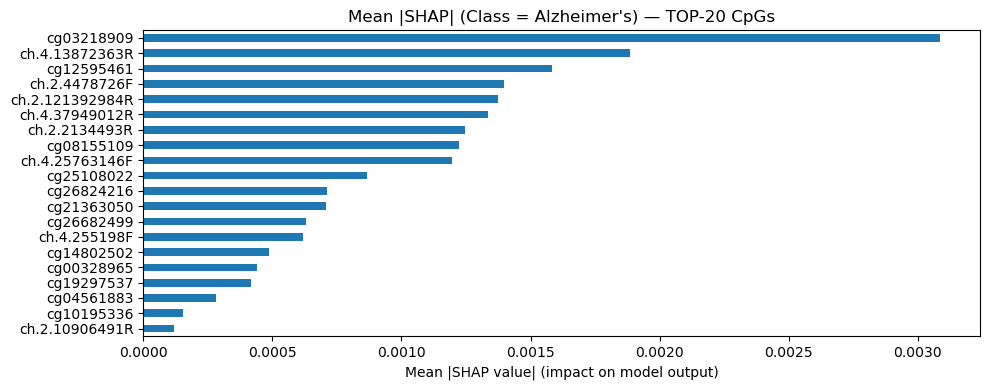

✅ Top-20 SHAP summary bar plot saved at: C:\Users\rakes\Documents\neet 2025\capstone\explainability_outputs\shap_top20_bar_fixed.png


In [34]:
# === Compute SHAP values and plot top-20 (robust) ===
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to import shap, install if missing
try:
    import shap
except Exception:
    print("shap not found — installing...")
    !{sys.executable} -m pip install shap --quiet
    import shap

# Confirm variables exist
if 'rf' not in globals():
    raise RuntimeError("rf (random forest model) not found in globals. Load it first.")
if 'X_full' not in globals() and 'X20' not in globals():
    raise RuntimeError("Neither X_full nor X20 found. Ensure the feature dataframe is loaded.")

# Choose features to explain:
# Prefer explaining X_full (full feature set) so explainer matches model features.
# If X_full is huge or absent, fallback to X20 (but explainer/model must accept same features).
X_input = X_full.copy() if 'X_full' in globals() else X20.copy()

# Ensure dataframe columns are strings and numeric dtype
X_input.columns = X_input.columns.astype(str)
X_input = X_input.apply(pd.to_numeric, errors='coerce')
if X_input.isnull().any().any():
    print("Warning: NaNs detected in X_input — filling with column means for SHAP compute.")
    X_input = X_input.fillna(X_input.mean())

print("Computing SHAP for input shape:", X_input.shape)

# Build TreeExplainer for RandomForest (fast)
explainer = shap.TreeExplainer(rf)

# Compute shap values
shap_values = explainer.shap_values(X_input)  # type could be list (per-class) or ndarray

# Standardize shap_values to numpy array with shape (n_samples, n_features, n_classes)
if isinstance(shap_values, list) or isinstance(shap_values, tuple):
    # shap_values is often list with length = n_classes, each is (n_samples, n_features)
    try:
        arr = np.stack([np.array(sv) for sv in shap_values], axis=-1)  # (n_samples, n_features, n_classes)
    except Exception:
        # sometimes shap returns (n_classes, n_samples, n_features)
        arr = np.array(shap_values)
        if arr.ndim == 3 and arr.shape[0] == len(shap_values):
            # transpose to (n_samples, n_features, n_classes)
            arr = np.transpose(arr, (1, 2, 0))
else:
    arr = np.array(shap_values)
    if arr.ndim == 3:
        # cases: (n_samples, n_features, n_classes) already OK
        pass
    elif arr.ndim == 2:
        # single-output model -> (n_samples, n_features); add classes dim=1
        arr = arr[:, :, np.newaxis]
    else:
        raise ValueError(f"Unexpected shap_values ndim: {arr.ndim}")

shap_array = arr  # now (n_samples, n_features, n_classes) expected
print("Standardized SHAP array shape:", shap_array.shape)

# Identify class index for "Alzheimer's" (class=1). If labels are {0,1}, use index 1.
n_classes = shap_array.shape[2]
if n_classes == 1:
    class_idx = 0
else:
    # try to map using y if available
    if 'y' in globals():
        unique_labels = np.unique(y)
        if set(unique_labels) <= {0,1}:
            # assume label 1 is AD -> use index where label==1 (usually index 1)
            class_idx = 1 if n_classes > 1 else 0
        else:
            # cannot be sure; choose index 1 if exists, else 0
            class_idx = 1 if n_classes > 1 else 0
    else:
        class_idx = 1 if n_classes > 1 else 0

print("Using class index:", class_idx, "out of", n_classes, "classes")

# Create series of mean(|SHAP|) for all features in X_input
shap_class = shap_array[:, :, class_idx]  # (n_samples, n_features)
shap_meanabs = np.abs(shap_class).mean(axis=0)  # (n_features,)
shap_meanabs_series = pd.Series(shap_meanabs, index=X_input.columns)

# Now select the top20 list you gave (ensure they exist in X_input)
missing_top20 = [c for c in top20 if c not in shap_meanabs_series.index]
if missing_top20:
    print("Warning: some top20 features not present in SHAP input and will be skipped:", missing_top20)

shap_top20 = shap_meanabs_series.loc[[c for c in top20 if c in shap_meanabs_series.index]]
# If any top20 were missing from user list, optionally fallback to overall top-20
if len(shap_top20) < 20:
    print(f"Found only {len(shap_top20)} of your top20 in SHAP input. Appending overall top features to reach 20.")
    others = shap_meanabs_series.drop(shap_top20.index).sort_values(ascending=False).head(20 - len(shap_top20))
    shap_top20 = pd.concat([shap_top20, others])

shap_top20 = shap_top20.sort_values(ascending=False)

# ---- Plot Top-20 SHAP Bar Graph ----
plt.figure(figsize=(10, 4))
shap_top20.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Mean |SHAP| (Class = Alzheimer's) — TOP-20 CpGs")
plt.xlabel("Mean |SHAP value| (impact on model output)")
plt.tight_layout()

bar_path = os.path.join(OUT_DIR, "shap_top20_bar_fixed.png")
plt.savefig(bar_path, dpi=200)
plt.show()

print("✅ Top-20 SHAP summary bar plot saved at:", bar_path)


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_parquet("final_merged_labeled.parquet")

# ✅ Your cleaned Top 20 CpGs list
top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883',
    'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499',
    'ch.2.10906491R', 'ch.2.121392984R', 'ch.2.2134493R',
    'ch.2.4478726F', 'cg08155109', 'cg26824216', 'cg21363050',
    'ch.4.13872363R', 'ch.4.255198F', 'ch.4.25763146F', 'ch.4.37949012R'
]

# ✅ Use ONLY Top 20 CpGs
X = df[top_cpgs]
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

# Train RF model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\n✅ Random Forest (Top 20 CpGs)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



✅ Random Forest (Top 20 CpGs)
Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       100
           1       0.91      0.96      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200


Confusion Matrix:
 [[90 10]
 [ 4 96]]


In [ ]:
#Random forest for top 20 cpg sites 

In [13]:
import pandas as pd
import numpy as np   # 👈 ADD THIS LINE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    log_loss,
    fbeta_score
)

# -----------------------------
# 1️⃣ Load data + Top 20 CpGs
# -----------------------------
# Final merged labeled dataset
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

# Top 20 CpGs list
top_cpg_file = "rfe_selected_top20_cpgs.csv"
top_cpgs_df = pd.read_csv(top_cpg_file)
top_cpgs = top_cpgs_df.iloc[:, 0].astype(str).tolist()
top_cpgs = [cpg for cpg in top_cpgs if cpg.startswith("cg") or cpg.startswith("ch")]

print("✅ Data shape:", df.shape)
print("🧬 Using Top 20 CpGs:", top_cpgs)
print("Count:", len(top_cpgs))

# -----------------------------
# 2️⃣ Define X, y (only Top 20 CpGs)
# -----------------------------
X = df[top_cpgs].copy()
y = df["label"].values

print("🧬 Feature shape (Top 20):", X.shape)
print("🎯 Target shape:", y.shape)

# -----------------------------
# 3️⃣ Train-Test Split (80/20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 4️⃣ Train Random Forest (same settings)
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -----------------------------
# 5️⃣ Predictions & Probabilities
# -----------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # probability for class "1"
print(y_proba[:20])
# -----------------------------
# 6️⃣ Metrics (Single Train-test Split)
# -----------------------------
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prc_auc = average_precision_score(y_test, y_proba)  # PRC-AUC
ll = log_loss(y_test, y_proba)
f2 = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ Random Forest (Top 20 CpGs) – Detailed Metrics")
print("🔹 Accuracy:           {:.3f}".format(acc))
print("🔹 Balanced Accuracy:  {:.3f}".format(bacc))
print("🔹 MCC:                {:.3f}".format(mcc))
print("🔹 ROC–AUC:            {:.3f}".format(roc_auc))
print("🔹 PRC–AUC:            {:.3f}".format(prc_auc))
print("🔹 Log Loss:           {:.3f}".format(ll))
print("🔹 F2-score:           {:.3f}".format(f2))

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 7️⃣ 10-Fold Stratified Cross-Validation
# -----------------------------
print("\n🚀 Running 10-fold Stratified Cross-Validation ...")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=18)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "f2": "fbeta",   # will pass beta via params below
}

# cross_validate doesn't allow beta directly in scoring dict,
# so we'll run a custom loop for F2 separately.

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "roc_auc", "f1"],
    n_jobs=-1,
    return_train_score=False
)

print("\n📈 10-Fold CV Results (mean ± std)")
print("Accuracy:          {:.3f} ± {:.3f}".format(cv_results["test_accuracy"].mean(),
                                                  cv_results["test_accuracy"].std()))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(cv_results["test_balanced_accuracy"].mean(),
                                                  cv_results["test_balanced_accuracy"].std()))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(cv_results["test_roc_auc"].mean(),
                                                  cv_results["test_roc_auc"].std()))
print("F1-score:          {:.3f} ± {:.3f}".format(cv_results["test_f1"].mean(),
                                                  cv_results["test_f1"].std()))

# ---------- Custom 10-fold F2 + MCC ----------
from sklearn.base import clone

f2_scores = []
mcc_scores = []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = clone(rf_model)
    model_cv.fit(X_tr, y_tr)
    y_pred_cv = model_cv.predict(X_te)

    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n🔹 F2-score (10-fold CV): {:.3f} ± {:.3f}".format(
    np.mean(f2_scores), np.std(f2_scores)
))
print("🔹 MCC (10-fold CV):      {:.3f} ± {:.3f}".format(
    np.mean(mcc_scores), np.std(mcc_scores)
))


✅ Data shape: (1000, 2297)
🧬 Using Top 20 CpGs: ['cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883', 'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R', 'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109', 'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F', 'ch.4.25763146F', 'ch.4.37949012R']
Count: 20
🧬 Feature shape (Top 20): (1000, 20)
🎯 Target shape: (1000,)
📊 Train: (800, 20) (800,)
📊 Test : (200, 20) (200,)
[0.7633333333 0.9816666667 0.9853333333 0.87         0.9566666667
 0.65         0.0066666667 0.915        0.8944444444 0.67
 0.0033333333 0.6866666667 0.9733333333 0.99         0.
 0.9294444444 0.4866666667 0.3833333333 0.0033333333 0.3077777778]

✅ Random Forest (Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.930
🔹 Balanced Accuracy:  0.930
🔹 MCC:                0.862
🔹 ROC–AUC:            0.952
🔹 PRC–AUC:            0.926
🔹 Log Loss:           0.257
🔹 F2-score:           0.949

📊 Classification Report:


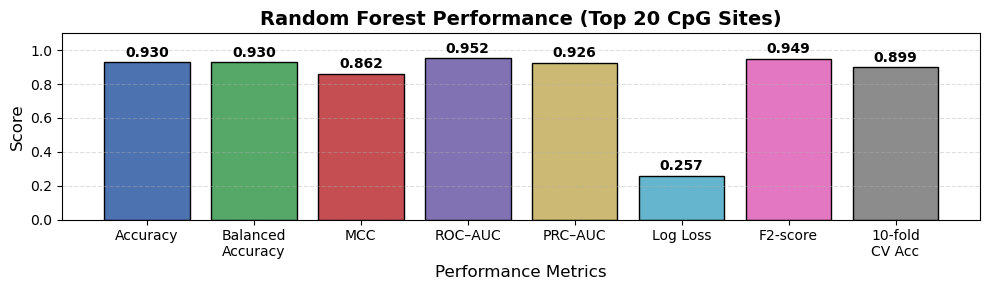

In [8]:
import matplotlib.pyplot as plt

# ---- Updated Metrics ----
metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "MCC",
    "ROC–AUC",
    "PRC–AUC",
    "Log Loss",
    "F2-score",
    "10-fold\nCV Acc"
]

scores = [
    0.930,  # Accuracy
    0.930,  # Balanced Accuracy
    0.862,  # MCC
    0.952,  # ROC–AUC
    0.926,  # PRC–AUC
    0.257,  # Log Loss
    0.949,  # F2-score
    0.899   # 10-fold CV Accuracy (mean)
]

# ---- Custom Colors for Each Bar ----
colors = [
    "#4C72B0",  # Blue
    "#55A868",  # Green
    "#C44E52",  # Red
    "#8172B3",  # Purple
    "#CCB974",  # Gold
    "#64B5CD",  # Teal
    "#E377C2",  # Pink
    "#8C8C8C"   # Grey
]

plt.figure(figsize=(10,3))

bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

# Add value labels
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10
    )

plt.ylabel("Score", fontsize=12)
plt.xlabel("Performance Metrics", fontsize=12)
plt.title("Random Forest Performance (Top 20 CpG Sites)", fontsize=14, fontweight="bold")

plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
#Logistic Regression – metrics + bar graph

✅ Data shape: (1000, 2297)
🧬 Feature shape (Top 20): (1000, 20)
🎯 Target shape: (1000,)
📊 Train: (800, 20) (800,)
📊 Test : (200, 20) (200,)
[0.1991930563 0.8592350391 0.9085875653 0.670579761  0.9731795368
 0.5059471642 0.0056289834 0.9882046584 0.9288050008 0.7057327094
 0.0181134322 0.8243374035 0.8195706233 0.923043282  0.0097475226
 0.902727953  0.6944319771 0.5355162816 0.0030026382 0.8349627656]
logistic regresion prob length: 200

✅ Logistic Regression (Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.860
🔹 Balanced Accuracy:  0.860
🔹 MCC:                0.729
🔹 ROC–AUC:            0.879
🔹 PRC–AUC:            0.779
🔹 Log Loss:           0.402
🔹 F2-score:           0.911

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       100
           1       0.81      0.94      0.87       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted 

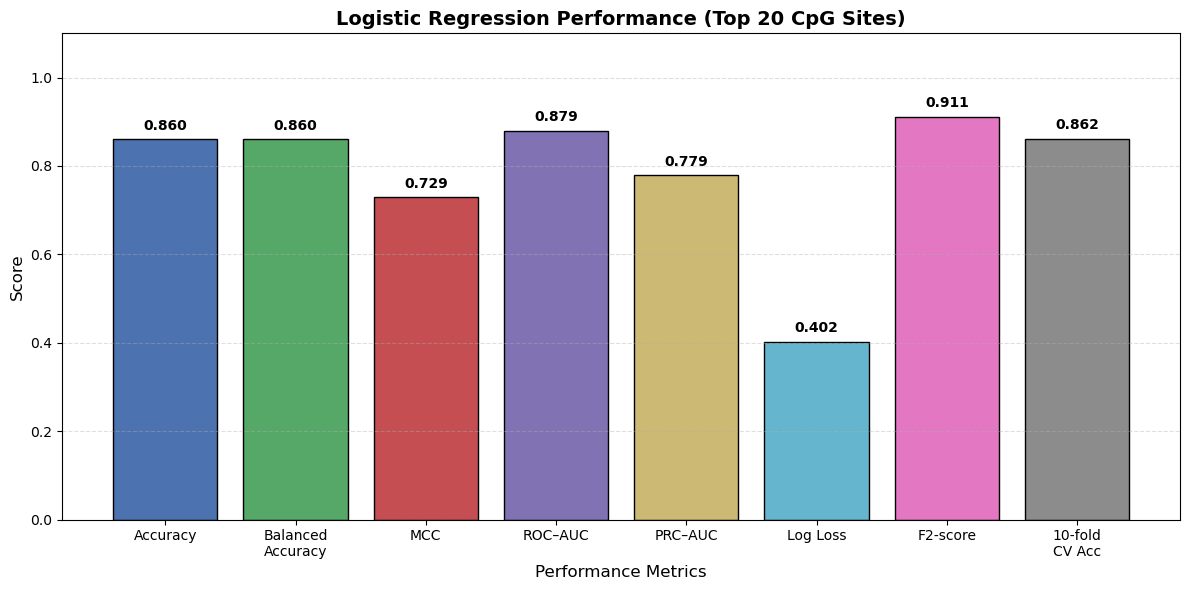

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, log_loss,
    fbeta_score, f1_score, confusion_matrix, classification_report
)

# -----------------------------
# 1. Load data & select Top 20 CpGs
# -----------------------------
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)
print("✅ Data shape:", df.shape)

top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883',
    'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R',
    'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
    'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F',
    'ch.4.25763146F', 'ch.4.37949012R'
]

X = df[top_cpgs]
y = df["label"].values

print("🧬 Feature shape (Top 20):", X.shape)
print("🎯 Target shape:", y.shape)

# -----------------------------
# 2. Train–test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=18
)
print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 3. Pipeline: StandardScaler + LogisticRegression
# -----------------------------
log_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

# -----------------------------
# 4. Test metrics
# -----------------------------
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]
LR_prob = y_proba
print(y_proba[:20])
print("logistic regresion prob length:",len(y_proba))
acc  = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
roc  = roc_auc_score(y_test, y_proba)
prc  = average_precision_score(y_test, y_proba)
ll   = log_loss(y_test, y_proba)
f2   = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ Logistic Regression (Top 20 CpGs) – Detailed Metrics")
print(f"🔹 Accuracy:           {acc:.3f}")
print(f"🔹 Balanced Accuracy:  {bacc:.3f}")
print(f"🔹 MCC:                {mcc:.3f}")
print(f"🔹 ROC–AUC:            {roc:.3f}")
print(f"🔹 PRC–AUC:            {prc:.3f}")
print(f"🔹 Log Loss:           {ll:.3f}")
print(f"🔹 F2-score:           {f2:.3f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 5. 10-fold Stratified CV
# -----------------------------
print("\n🚀 Running 10-fold Stratified Cross-Validation ...")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=18)

acc_scores  = []
bacc_scores = []
roc_scores  = []
f1_scores   = []
f2_scores   = []
mcc_scores  = []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            n_jobs=-1,
            random_state=42
        ))
    ])
    model_cv.fit(X_tr, y_tr)
    y_pred_cv = model_cv.predict(X_te)
    y_proba_cv = model_cv.predict_proba(X_te)[:, 1]

    acc_scores.append(accuracy_score(y_te, y_pred_cv))
    bacc_scores.append(balanced_accuracy_score(y_te, y_pred_cv))
    roc_scores.append(roc_auc_score(y_te, y_proba_cv))
    f1_scores.append(f1_score(y_te, y_pred_cv))
    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n📈 10-Fold CV Results (mean ± std)")
print("Accuracy:          {:.3f} ± {:.3f}".format(np.mean(acc_scores),  np.std(acc_scores)))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(np.mean(bacc_scores), np.std(bacc_scores)))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(np.mean(roc_scores),  np.std(roc_scores)))
print("F1-score:          {:.3f} ± {:.3f}".format(np.mean(f1_scores),   np.std(f1_scores)))
print("F2-score:          {:.3f} ± {:.3f}".format(np.mean(f2_scores),   np.std(f2_scores)))
print("MCC:               {:.3f} ± {:.3f}".format(np.mean(mcc_scores),  np.std(mcc_scores)))

cv_acc_mean = np.mean(acc_scores)

# -----------------------------
# 6. Bar plot (like RF one)
# -----------------------------
metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "MCC",
    "ROC–AUC",
    "PRC–AUC",
    "Log Loss",
    "F2-score",
    "10-fold\nCV Acc"
]

scores = [acc, bacc, mcc, roc, prc, ll, f2, cv_acc_mean]

colors = [
    "#4C72B0", "#55A868", "#C44E52", "#8172B3",
    "#CCB974", "#64B5CD", "#E377C2", "#8C8C8C"
]

plt.figure(figsize=(12,6))
bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.015,
        f"{score:.3f}",
        ha="center", va="bottom",
        fontweight="bold", fontsize=10
    )

plt.ylabel("Score", fontsize=12)
plt.xlabel("Performance Metrics", fontsize=12)
plt.title("Logistic Regression Performance (Top 20 CpG Sites)", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
#SVM (RBF kernel) – metrics + bar graph


🔹 SVM probabilities (first 20 samples):
[0.5280377435 0.8182040175 0.8804292306 0.5765510927 0.8458877253
 0.2732637945 0.015495385  0.9474730325 0.8495108724 0.7207894148
 0.0163442248 0.6152973573 0.8214046836 0.8829041571 0.0143906283
 0.8029463305 0.6891310348 0.6343021383 0.0149747115 0.7660912701]
SVM prob length: 200

✅ SVM (RBF, Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.885
🔹 Balanced Accuracy:  0.885
🔹 MCC:                0.784
🔹 ROC–AUC:            0.913
🔹 PRC–AUC:            0.816
🔹 Log Loss:           0.305
🔹 F2-score:           0.944

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       100
           1       0.82      0.98      0.89       100

    accuracy                           0.89       200
   macro avg       0.90      0.89      0.88       200
weighted avg       0.90      0.89      0.88       200

🧭 Confusion Matrix:
[[79 21]
 [ 2 98]]

🚀 Running 10-fold Stratified Cross-Vali

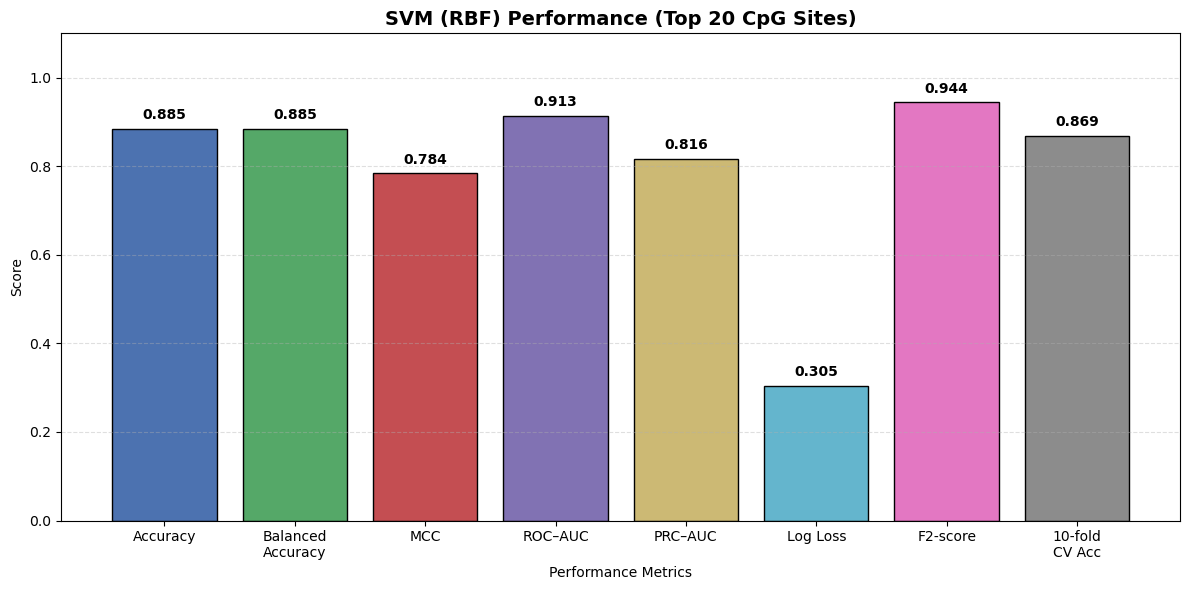

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, log_loss,
    fbeta_score, f1_score, confusion_matrix, classification_report
)

# 1. Load data
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883',
    'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R',
    'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
    'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F',
    'ch.4.25763146F', 'ch.4.37949012R'
]

X = df[top_cpgs]
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=18
)

# 2. SVM pipeline (scaling + probability=True)
svm_clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_clf.fit(X_train, y_train)

# 3. Test metrics
y_pred = svm_clf.predict(X_test)
y_proba = svm_clf.predict_proba(X_test)[:, 1]
SVM_prob = y_proba
print("\n🔹 SVM probabilities (first 20 samples):")
print(y_proba[:20])
print("SVM prob length:",len(y_proba))
acc  = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
roc  = roc_auc_score(y_test, y_proba)
prc  = average_precision_score(y_test, y_proba)
ll   = log_loss(y_test, y_proba)
f2   = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ SVM (RBF, Top 20 CpGs) – Detailed Metrics")
print(f"🔹 Accuracy:           {acc:.3f}")
print(f"🔹 Balanced Accuracy:  {bacc:.3f}")
print(f"🔹 MCC:                {mcc:.3f}")
print(f"🔹 ROC–AUC:            {roc:.3f}")
print(f"🔹 PRC–AUC:            {prc:.3f}")
print(f"🔹 Log Loss:           {ll:.3f}")
print(f"🔹 F2-score:           {f2:.3f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 4. 10-fold CV
print("\n🚀 Running 10-fold Stratified Cross-Validation ...")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=18)

acc_scores  = []
bacc_scores = []
roc_scores  = []
f1_scores   = []
f2_scores   = []
mcc_scores  = []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale",
                    probability=True, random_state=42))
    ])
    model_cv.fit(X_tr, y_tr)
    y_pred_cv = model_cv.predict(X_te)
    y_proba_cv = model_cv.predict_proba(X_te)[:, 1]

    acc_scores.append(accuracy_score(y_te, y_pred_cv))
    bacc_scores.append(balanced_accuracy_score(y_te, y_pred_cv))
    roc_scores.append(roc_auc_score(y_te, y_proba_cv))
    f1_scores.append(f1_score(y_te, y_pred_cv))
    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n📈 10-Fold CV Results (mean ± std)")
print("Accuracy:          {:.3f} ± {:.3f}".format(np.mean(acc_scores),  np.std(acc_scores)))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(np.mean(bacc_scores), np.std(bacc_scores)))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(np.mean(roc_scores),  np.std(roc_scores)))
print("F1-score:          {:.3f} ± {:.3f}".format(np.mean(f1_scores),   np.std(f1_scores)))
print("F2-score:          {:.3f} ± {:.3f}".format(np.mean(f2_scores),   np.std(f2_scores)))
print("MCC:               {:.3f} ± {:.3f}".format(np.mean(mcc_scores),  np.std(mcc_scores)))

cv_acc_mean = np.mean(acc_scores)

# 5. Bar plot
metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "MCC",
    "ROC–AUC",
    "PRC–AUC",
    "Log Loss",
    "F2-score",
    "10-fold\nCV Acc"
]

scores = [acc, bacc, mcc, roc, prc, ll, f2, cv_acc_mean]

colors = [
    "#4C72B0", "#55A868", "#C44E52", "#8172B3",
    "#CCB974", "#64B5CD", "#E377C2", "#8C8C8C"
]

plt.figure(figsize=(12,6))
bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.015,
        f"{score:.3f}",
        ha="center", va="bottom",
        fontweight="bold", fontsize=10
    )

plt.ylabel("Score")
plt.xlabel("Performance Metrics")
plt.title("SVM (RBF) Performance (Top 20 CpG Sites)", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
#Decision Tree – metrics + bar graph


🔹 Decision Tree probabilities (first 20 samples):
[1.  1.  1.  1.  1.  1.  0.  1.  1.  0.4 0.  0.6 1.  1.  0.  1.  0.2 0.
 0.  0. ]

✅ Decision Tree (Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.860
🔹 Balanced Accuracy:  0.860
🔹 MCC:                0.720
🔹 ROC–AUC:            0.910
🔹 PRC–AUC:            0.863
🔹 Log Loss:           2.954
🔹 F2-score:           0.860

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       100
           1       0.86      0.86      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

🧭 Confusion Matrix:
[[86 14]
 [14 86]]

🚀 Running 10-fold Stratified Cross-Validation ...

📈 10-Fold CV Results (mean ± std)
Accuracy:          0.844 ± 0.025
Balanced Accuracy: 0.844 ± 0.025
ROC–AUC:           0.869 ± 0.025
F1-score:          0.843 ± 0.025
F2-score:  

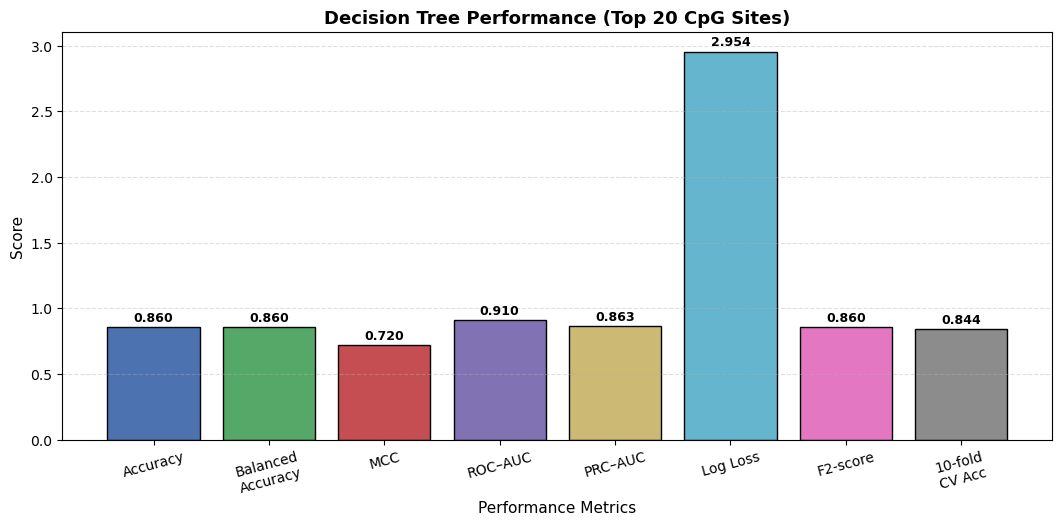

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, log_loss,
    fbeta_score, f1_score, confusion_matrix, classification_report
)

file_path =  "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883',
    'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R',
    'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
    'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F',
    'ch.4.25763146F', 'ch.4.37949012R'
]

X = df[top_cpgs]
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=18
)

dt_clf = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=6,
    min_samples_leaf=1,
    random_state=42
)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)
y_proba = dt_clf.predict_proba(X_test)[:, 1]
DT_prob = y_proba
print("\n🔹 Decision Tree probabilities (first 20 samples):")
print(y_proba[:20])


acc  = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
roc  = roc_auc_score(y_test, y_proba)
prc  = average_precision_score(y_test, y_proba)
ll   = log_loss(y_test, y_proba)
f2   = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ Decision Tree (Top 20 CpGs) – Detailed Metrics")
print(f"🔹 Accuracy:           {acc:.3f}")
print(f"🔹 Balanced Accuracy:  {bacc:.3f}")
print(f"🔹 MCC:                {mcc:.3f}")
print(f"🔹 ROC–AUC:            {roc:.3f}")
print(f"🔹 PRC–AUC:            {prc:.3f}")
print(f"🔹 Log Loss:           {ll:.3f}")
print(f"🔹 F2-score:           {f2:.3f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("🧭 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n🚀 Running 10-fold Stratified Cross-Validation ...")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=18)

acc_scores  = []
bacc_scores = []
roc_scores  = []
f1_scores   = []
f2_scores   = []
mcc_scores  = []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = DecisionTreeClassifier(
        max_depth=30,
        min_samples_split=6,
        min_samples_leaf=1,
        random_state=42
    )
    model_cv.fit(X_tr, y_tr)
    y_pred_cv = model_cv.predict(X_te)
    y_proba_cv = model_cv.predict_proba(X_te)[:, 1]

    acc_scores.append(accuracy_score(y_te, y_pred_cv))
    bacc_scores.append(balanced_accuracy_score(y_te, y_pred_cv))
    roc_scores.append(roc_auc_score(y_te, y_proba_cv))
    f1_scores.append(f1_score(y_te, y_pred_cv))
    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n📈 10-Fold CV Results (mean ± std)")
print("Accuracy:          {:.3f} ± {:.3f}".format(np.mean(acc_scores),  np.std(acc_scores)))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(np.mean(bacc_scores), np.std(bacc_scores)))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(np.mean(roc_scores),  np.std(roc_scores)))
print("F1-score:          {:.3f} ± {:.3f}".format(np.mean(f1_scores),   np.std(f1_scores)))
print("F2-score:          {:.3f} ± {:.3f}".format(np.mean(f2_scores),   np.std(f2_scores)))
print("MCC:               {:.3f} ± {:.3f}".format(np.mean(mcc_scores),  np.std(mcc_scores)))

cv_acc_mean = np.mean(acc_scores)

import matplotlib.pyplot as plt
import numpy as np  # make sure this is imported once at top of notebook

metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "MCC",
    "ROC–AUC",
    "PRC–AUC",
    "Log Loss",
    "F2-score",
    "10-fold\nCV Acc"
]

scores = [acc, bacc, mcc, roc, prc, ll, f2, cv_acc_mean]

colors = [
    "#4C72B0", "#55A868", "#C44E52", "#8172B3",
    "#CCB974", "#64B5CD", "#E377C2", "#8C8C8C"
]

plt.figure(figsize=(11, 6))  # slightly smaller & wider

bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

# value labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9
    )

plt.ylabel("Score", fontsize=11)
plt.xlabel("Performance Metrics", fontsize=11)
plt.title("Decision Tree Performance (Top 20 CpG Sites)", fontsize=13, fontweight="bold")

plt.ylim(0, max(scores) + 0.15)  # add a bit of headroom
plt.xticks(rotation=15)          # tilt labels slightly to avoid collision
plt.grid(axis="y", linestyle="--", alpha=0.4)

# instead of tight_layout() (which was complaining), set margins manually
plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.20)

plt.show()


✅ Data shape: (1000, 2297)
🧬 Feature shape: (1000, 20)
🎯 Target shape: (1000,)

✅ XGBoost (Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.91
🔹 Balanced Accuracy:  0.91
🔹 MCC:                0.821
🔹 ROC–AUC:            0.95
🔹 PRC–AUC:            0.918
🔹 Log Loss:           0.321
🔹 F2-score:           0.923

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91       100
           1       0.89      0.93      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

🧭 Confusion Matrix:
 [[89 11]
 [ 7 93]]

📈 10-Fold CV Results (mean ± std)
Accuracy:          0.893 ± 0.028
Balanced Accuracy: 0.893 ± 0.028
ROC–AUC:           0.945 ± 0.017
F1-score:          0.897 ± 0.028
F2-score:          0.921 ± 0.033
MCC:               0.790 ± 0.056
[0.8913212    0.9953074    0.9985499    0.97786885   0.97

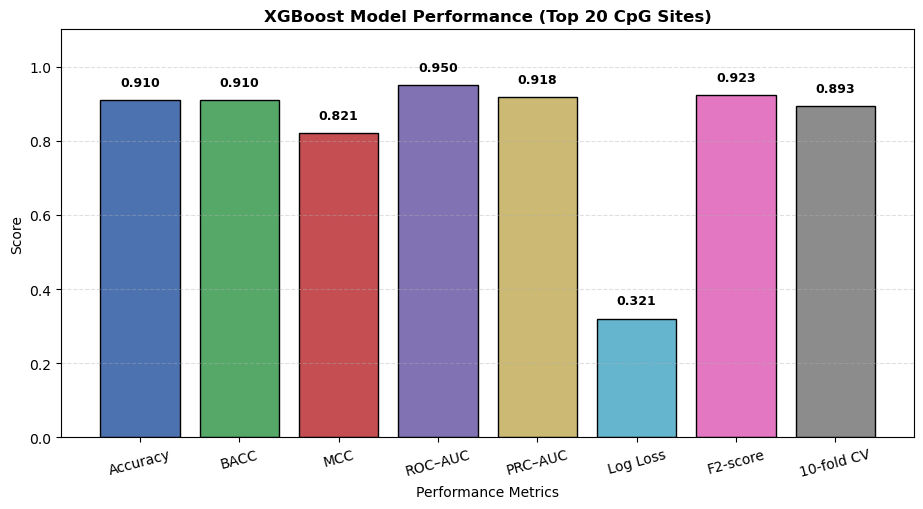

In [29]:
# -----------------------------
# 🔥 XGBoost Model (Top 20 CpGs) - Full Pipeline
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score,
    average_precision_score, log_loss,
    fbeta_score, classification_report,
    confusion_matrix, f1_score
)

# -----------------------------
# 1️⃣ Load Dataset
# -----------------------------
file_path =  "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

# ✅ Your Top 20 CpG list
top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537',
    'cg04561883', 'cg00328965', 'cg03218909', 'cg12595461',
    'cg26682499', 'ch.2.10906491R', 'ch.2.121392984R',
    'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
    'cg26824216', 'cg21363050', 'ch.4.13872363R',
    'ch.4.255198F', 'ch.4.25763146F', 'ch.4.37949012R'
]

# -----------------------------
# 2️⃣ Select Features & Target
# -----------------------------
X = df[top_cpgs]
y = df["label"]

print("✅ Data shape:", df.shape)
print("🧬 Feature shape:", X.shape)
print("🎯 Target shape:", y.shape)

# -----------------------------
# 3️⃣ Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

# -----------------------------
# 4️⃣ Train XGBoost Model
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
# -----------------------------
# 5️⃣ Predictions
# -----------------------------
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
XGB_prob = y_proba

# -----------------------------
# 6️⃣ Test Metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
prc = average_precision_score(y_test, y_prob)
ll = log_loss(y_test, y_prob)
f2 = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ XGBoost (Top 20 CpGs) – Detailed Metrics")
print("🔹 Accuracy:          ", round(acc, 3))
print("🔹 Balanced Accuracy: ", round(bacc, 3))
print("🔹 MCC:               ", round(mcc, 3))
print("🔹 ROC–AUC:           ", round(roc, 3))
print("🔹 PRC–AUC:           ", round(prc, 3))
print("🔹 Log Loss:          ", round(ll, 3))
print("🔹 F2-score:          ", round(f2, 3))

print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧭 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -----------------------------
# 7️⃣ 10-Fold Cross-Validation
# -----------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = []
bacc_scores = []
roc_scores = []
f1_scores = []
f2_scores = []
mcc_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_tr, y_tr)
    y_pred_cv = model.predict(X_te)
    y_prob_cv = model.predict_proba(X_te)[:, 1]

    acc_scores.append(accuracy_score(y_te, y_pred_cv))
    bacc_scores.append(balanced_accuracy_score(y_te, y_pred_cv))
    roc_scores.append(roc_auc_score(y_te, y_prob_cv))
    f1_scores.append(f1_score(y_te, y_pred_cv))
    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n📈 10-Fold CV Results (mean ± std)")
print("Accuracy:          {:.3f} ± {:.3f}".format(np.mean(acc_scores), np.std(acc_scores)))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(np.mean(bacc_scores), np.std(bacc_scores)))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(np.mean(roc_scores), np.std(roc_scores)))
print("F1-score:          {:.3f} ± {:.3f}".format(np.mean(f1_scores), np.std(f1_scores)))
print("F2-score:          {:.3f} ± {:.3f}".format(np.mean(f2_scores), np.std(f2_scores)))
print("MCC:               {:.3f} ± {:.3f}".format(np.mean(mcc_scores), np.std(mcc_scores)))
print(xgb_prob[:20])
cv_acc_mean = np.mean(acc_scores)

# -----------------------------
# 8️⃣ Bar Graph (Journal-style)
# -----------------------------
metrics = [
    "Accuracy", "BACC", "MCC",
    "ROC–AUC", "PRC–AUC",
    "Log Loss", "F2-score",
    "10-fold CV"
]

scores = [acc, bacc, mcc, roc, prc, ll, f2, cv_acc_mean]

colors = [
    "#4C72B0", "#55A868", "#C44E52",
    "#8172B3", "#CCB974", "#64B5CD",
    "#E377C2", "#8C8C8C"
]

plt.figure(figsize=(11, 6))
bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9
    )

plt.ylabel("Score")
plt.xlabel("Performance Metrics")
plt.title("XGBoost Model Performance (Top 20 CpG Sites)", fontweight="bold")
plt.ylim(0, max(scores) + 0.15)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.subplots_adjust(bottom=0.2)
plt.show()


In [7]:
import numpy as np

# Original array (scientific notation)
arr = np.array([
    8.9132118e-01, 9.9530739e-01, 9.9854988e-01, 9.7786885e-01, 9.7819692e-01,
    3.8949701e-01, 2.4234313e-03, 9.9482685e-01, 9.8494059e-01, 7.9541475e-01,
    2.9257231e-04, 4.1367507e-01, 9.9296510e-01, 9.9502915e-01, 5.9726933e-04,
    9.8328412e-01, 4.9330696e-01, 2.3872583e-01, 9.9522283e-04, 6.2592469e-02
])

# Convert & display as normal floats
np.set_printoptions(suppress=True, precision=10)
print(arr.tolist())


[0.89132118, 0.99530739, 0.99854988, 0.97786885, 0.97819692, 0.38949701, 0.0024234313, 0.99482685, 0.98494059, 0.79541475, 0.00029257231, 0.41367507, 0.9929651, 0.99502915, 0.00059726933, 0.98328412, 0.49330696, 0.23872583, 0.00099522283, 0.062592469]


In [6]:
import pandas as pd

# Path to your parquet file
file_path ="final_merged_labeled.parquet"

# Read parquet file
df = pd.read_parquet(file_path)

# 1️⃣ Show shape (rows, columns)
print("Shape of data:", df.shape)

# 2️⃣ Show column names
print("\nColumns in the file:")
print(df.columns.tolist())

# 3️⃣ Show first 5 rows
print("\nFirst 5 rows:")
print(df.head())

# 4️⃣ Show data types
print("\nData types:")
print(df.dtypes)

# 5️⃣ Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Shape of data: (1000, 2297)

Columns in the file:
['sample_id', 'cg00031256', 'cg00115458', 'cg00237391', 'cg00657529', 'cg00744524', 'cg00844120', 'cg01516851', 'cg02004337', 'cg02087565', 'cg02272968', 'cg02612397', 'cg02770672', 'cg03134653', 'cg03298716', 'cg03355690', 'cg03791799', 'cg03826642', 'cg03891442', 'cg04471092', 'cg05583848', 'cg05696678', 'cg05728019', 'cg05740106', 'cg05789702', 'cg05839741', 'cg06321045', 'cg06347083', 'cg06444195', 'cg06623698', 'cg06815976', 'cg07041218', 'cg07068382', 'cg07355507', 'cg07858113', 'cg07893921', 'cg08125488', 'cg08132025', 'cg08155050', 'cg08200507', 'cg08828723', 'cg08864375', 'cg08956463', 'cg09059466', 'cg09091941', 'cg09114581', 'cg09703840', 'cg09883659', 'cg10490099', 'cg10647833', 'cg10651618', 'cg10674805', 'cg10698889', 'cg10849498', 'cg10851350', 'cg10893014', 'cg11230112', 'cg11496630', 'cg11600186', 'cg11724750', 'cg11810743', 'cg11984911', 'cg12419863', 'cg12465250', 'cg13192239', 'cg13280041', 'cg13351249', 'cg13369325'

✅ Data shape: (1000, 2297)
🧬 Feature shape (Top 20): (1000, 20)
🎯 Target shape: (1000,)
📊 Train: (800, 20) (800,)
📊 Test : (200, 20) (200,)

🚀 Starting RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Hyperparameters Found:
{'max_depth': 30, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 574}
🌿 Best CV Accuracy: 0.887
[1.  1.  1.  1.  1.  1.  0.  1.  1.  0.4 0.  0.6 1.  1.  0.  1.  0.2 0.
 0.  0. ]

✅ Tuned Random Forest (Top 20 CpGs) – Detailed Metrics
🔹 Accuracy:           0.915
🔹 Balanced Accuracy:  0.915
🔹 MCC:                0.832
🔹 ROC–AUC:            0.944
🔹 PRC–AUC:            0.905
🔹 Log Loss:           0.285
🔹 F2-score:           0.937

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91       100
           1       0.89      0.95      0.92       100

    accuracy                           0.92       200
   

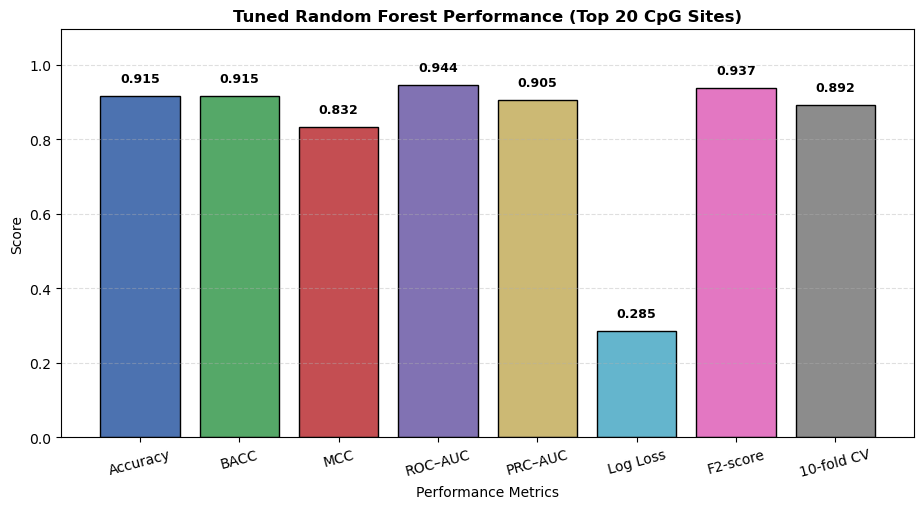

In [28]:
# -----------------------------
# 🌲 Random Forest Hyperparameter Tuning (Top 20 CpGs)
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score,
    average_precision_score, log_loss,
    fbeta_score, f1_score,
    classification_report, confusion_matrix
)
from scipy.stats import randint, uniform

# -----------------------------
# 1️⃣ Load dataset
# -----------------------------
file_path = "final_merged_labeled.parquet"
df = pd.read_parquet(file_path)

# ✅ Your Top 20 CpGs
top_cpgs = [
    'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537',
    'cg04561883', 'cg00328965', 'cg03218909', 'cg12595461',
    'cg26682499', 'ch.2.10906491R', 'ch.2.121392984R',
    'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
    'cg26824216', 'cg21363050', 'ch.4.13872363R',
    'ch.4.255198F', 'ch.4.25763146F', 'ch.4.37949012R'
]

X = df[top_cpgs]
y = df["label"]

print("✅ Data shape:", df.shape)
print("🧬 Feature shape (Top 20):", X.shape)
print("🎯 Target shape:", y.shape)

# -----------------------------
# 2️⃣ Train-Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=18,
    stratify=y
)

print("📊 Train:", X_train.shape, y_train.shape)
print("📊 Test :", X_test.shape, y_test.shape)

# -----------------------------
# 3️⃣ Define RF + Hyperparameter Search Space
# -----------------------------
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(100, 600),          # number of trees
    "max_depth": [None, 5, 10, 20, 30],         # tree depth
    "min_samples_split": randint(2, 15),        # minimum samples to split
    "min_samples_leaf": randint(1, 8),          # min samples in a leaf
    "max_features": ["sqrt", "log2", 0.5, 0.8]  # feature subset per split
}

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,                # number of random combos
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("\n🚀 Starting RandomizedSearchCV for Random Forest...")
random_search.fit(X_train, y_train)

print("\n✅ Best Hyperparameters Found:")
print(random_search.best_params_)
print("🌿 Best CV Accuracy: {:.3f}".format(random_search.best_score_))

# -----------------------------
# 4️⃣ Evaluate Tuned RF on Test Set
# -----------------------------
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]
RF_proba = y_prob
print(y_proba[:20])
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
prc = average_precision_score(y_test, y_prob)
ll = log_loss(y_test, y_prob)
f2 = fbeta_score(y_test, y_pred, beta=2)

print("\n✅ Tuned Random Forest (Top 20 CpGs) – Detailed Metrics")
print("🔹 Accuracy:           {:.3f}".format(acc))
print("🔹 Balanced Accuracy:  {:.3f}".format(bacc))
print("🔹 MCC:                {:.3f}".format(mcc))
print("🔹 ROC–AUC:            {:.3f}".format(roc))
print("🔹 PRC–AUC:            {:.3f}".format(prc))
print("🔹 Log Loss:           {:.3f}".format(ll))
print("🔹 F2-score:           {:.3f}".format(f2))

print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧭 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -----------------------------
# 5️⃣ 10-Fold Stratified Cross-Validation (with best params)
# -----------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = []
bacc_scores = []
roc_scores = []
f1_scores = []
f2_scores = []
mcc_scores = []

print("\n🚀 Running 10-fold Stratified Cross-Validation ...")

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        **random_search.best_params_,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    y_pred_cv = model.predict(X_te)
    y_prob_cv = model.predict_proba(X_te)[:, 1]

    acc_scores.append(accuracy_score(y_te, y_pred_cv))
    bacc_scores.append(balanced_accuracy_score(y_te, y_pred_cv))
    roc_scores.append(roc_auc_score(y_te, y_prob_cv))
    f1_scores.append(f1_score(y_te, y_pred_cv))
    f2_scores.append(fbeta_score(y_te, y_pred_cv, beta=2))
    mcc_scores.append(matthews_corrcoef(y_te, y_pred_cv))

print("\n📈 10-Fold CV Results (mean ± std)")
cv_acc_mean, cv_acc_std = np.mean(acc_scores), np.std(acc_scores)
cv_bacc_mean, cv_bacc_std = np.mean(bacc_scores), np.std(bacc_scores)
cv_roc_mean, cv_roc_std = np.mean(roc_scores), np.std(roc_scores)
cv_f1_mean, cv_f1_std = np.mean(f1_scores), np.std(f1_scores)
cv_f2_mean, cv_f2_std = np.mean(f2_scores), np.std(f2_scores)
cv_mcc_mean, cv_mcc_std = np.mean(mcc_scores), np.std(mcc_scores)

print("Accuracy:          {:.3f} ± {:.3f}".format(cv_acc_mean, cv_acc_std))
print("Balanced Accuracy: {:.3f} ± {:.3f}".format(cv_bacc_mean, cv_bacc_std))
print("ROC–AUC:           {:.3f} ± {:.3f}".format(cv_roc_mean, cv_roc_std))
print("F1-score:          {:.3f} ± {:.3f}".format(cv_f1_mean, cv_f1_std))
print("F2-score:          {:.3f} ± {:.3f}".format(cv_f2_mean, cv_f2_std))
print("MCC:               {:.3f} ± {:.3f}".format(cv_mcc_mean, cv_mcc_std))

# -----------------------------
# 6️⃣ Bar Plot of Metrics (Tuned RF)
# -----------------------------
metrics = [
    "Accuracy", "BACC", "MCC",
    "ROC–AUC", "PRC–AUC",
    "Log Loss", "F2-score",
    "10-fold CV"
]

scores = [
    acc, bacc, mcc,
    roc, prc,
    ll, f2,
    cv_acc_mean
]

colors = [
    "#4C72B0", "#55A868", "#C44E52",
    "#8172B3", "#CCB974",
    "#64B5CD", "#E377C2",
    "#8C8C8C"
]

plt.figure(figsize=(11, 6))
bars = plt.bar(metrics, scores, color=colors, edgecolor="black", linewidth=1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9
    )

plt.ylabel("Score")
plt.xlabel("Performance Metrics")
plt.title("Tuned Random Forest Performance (Top 20 CpG Sites)", fontweight="bold")
plt.ylim(0, max(scores) + 0.15)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.subplots_adjust(bottom=0.2)
plt.show()


In [35]:
print(
    len(RF_proba),
    len(DT_prob),
    len(SVM_prob),
    len(XGB_prob),
    len(LR_prob)
)


200 200 200 200 200




🎯 Final Comparison Table Across All Models:

                     Accuracy  Balanced Accuracy  ROC-AUC   PRC-AUC       MCC  \
Random Forest           0.920              0.920   0.9513  0.917834  0.842701   
Logistic Regression     0.845              0.845   0.8971  0.846649  0.702802   
SVM                     0.880              0.880   0.9128  0.821984  0.779088   
Decision Tree           0.890              0.890   0.8900  0.916176  0.780156   
XGBoost                 0.925              0.925   0.9468  0.899635  0.852090   

                           F1        F2  Log Loss  
Random Forest        0.923077  0.944882  0.262036  
Logistic Regression  0.858447  0.905588  0.351136  
SVM                  0.891892  0.948276  0.298519  
Decision Tree        0.891089  0.896414  3.964802  
XGBoost              0.927536  0.946746  0.271427  


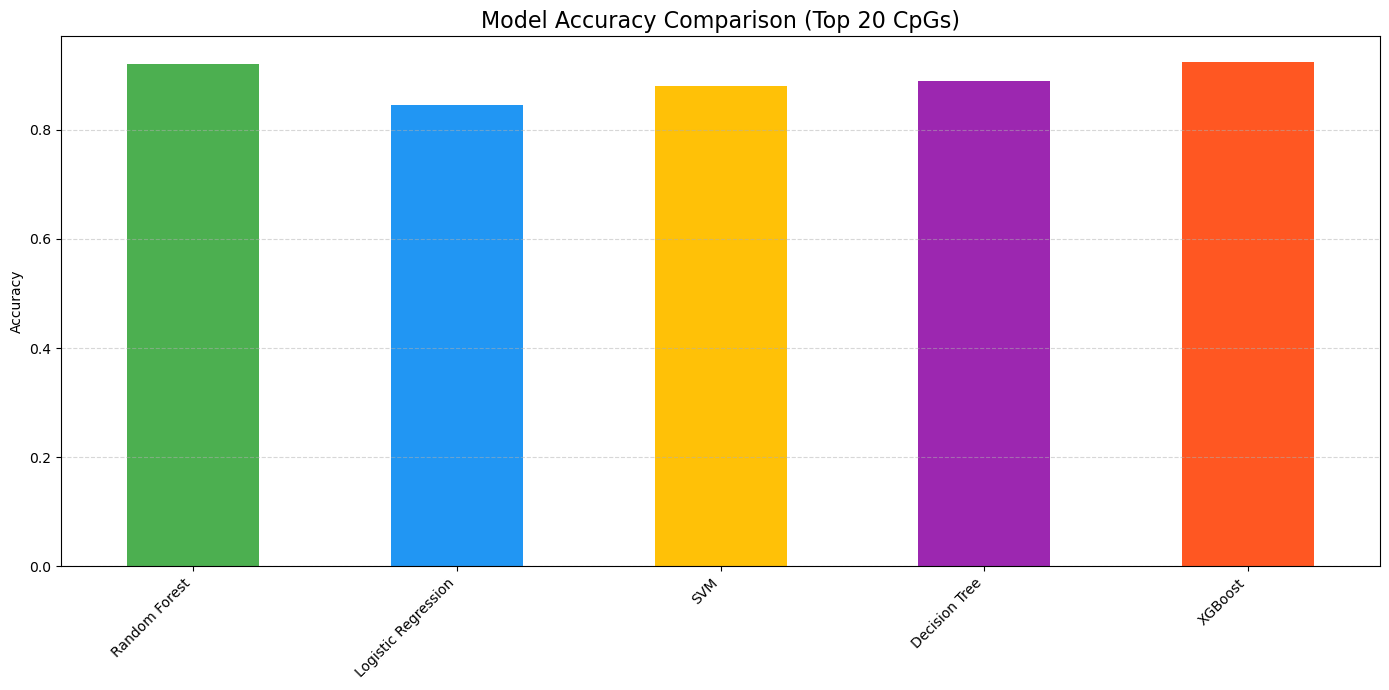

In [13]:
# =========================================
# 1️⃣ Imports
# =========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef, 
    roc_auc_score, f1_score, fbeta_score, log_loss,
    precision_recall_curve, auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

# =========================================
# 2️⃣ Load data
# =========================================
df = pd.read_parquet("final_merged_labeled.parquet")

# Load top 20 CpGs list
top_cpgs = [
'cg14802502', 'cg25108022', 'cg10195336', 'cg19297537', 'cg04561883',
'cg00328965', 'cg03218909', 'cg12595461', 'cg26682499', 'ch.2.10906491R',
'ch.2.121392984R', 'ch.2.2134493R', 'ch.2.4478726F', 'cg08155109',
'cg26824216', 'cg21363050', 'ch.4.13872363R', 'ch.4.255198F',
'ch.4.25763146F', 'ch.4.37949012R'
]

X = df[top_cpgs]
y = df["label"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18, stratify=y
)

# =========================================
# 3️⃣ Model Dictionary
# =========================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=18),
    "Logistic Regression": LogisticRegression(max_iter=3000, n_jobs=-1),
    "SVM": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=18),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss"
    )
}

# =========================================
# 4️⃣ Function to calculate metrics
# =========================================
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    prc_auc = auc(recall, precision)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PRC-AUC": prc_auc,
        "MCC": matthews_corrcoef(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "F2": fbeta_score(y_test, y_pred, beta=2),
        "Log Loss": log_loss(y_test, y_prob)
    }

# =========================================
# 5️⃣ Evaluate all models
# =========================================
results = {}
for name, model in models.items():
    results[name] = evaluate_model(name, model)

df_results = pd.DataFrame(results).T
print("\n\n🎯 Final Comparison Table Across All Models:\n")
print(df_results)

# =========================================
# 6️⃣ Plot Comparison Graph
# =========================================
plt.figure(figsize=(14, 7))
colors = ['#4caf50', '#2196F3', '#FFC107', '#9C27B0', '#FF5722']  # different decent colors

df_results["Accuracy"].plot(kind="bar", color=colors)

plt.title("Model Accuracy Comparison (Top 20 CpGs)", fontsize=16)
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


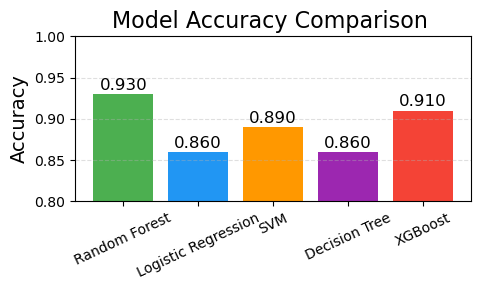

In [14]:
import matplotlib.pyplot as plt

# Accuracies BEFORE hyperparameter tuning
model_names = [
    "Random Forest",
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "XGBoost"
]

accuracies = [0.93, 0.86,   0.89, 0.86, 0.91]

# Beautiful distinct colors
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

plt.figure(figsize=(5, 3))
bars = plt.bar(model_names, accuracies, color=colors)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f"{acc:.3f}", ha='center', fontsize=12)

plt.title("Model Accuracy Comparison ", fontsize=16)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.80, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [15]:
'rf_model' in globals()


True

In [16]:
import joblib
joblib.dump(rf_model, "rf_top20_model.pkl")
print("Saved → rf_top20_model.pkl")


Saved → rf_top20_model.pkl


In [35]:
import joblib
import numpy as np

# Load model
rf_loaded = joblib.load("rf_top20_model.pkl")

print("Loaded model type:", type(rf_loaded))

# Test predict on sample
sample = X20.iloc[0:3]   # first 3 rows
pred = rf_loaded.predict(sample)

print("Sample predictions:", pred)


Loaded model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Sample predictions: [1 1 1]


In [ ]:
#Merging the model probabilities

In [36]:
X_ann = np.column_stack([RF_proba, DT_prob, SVM_prob, XGB_prob, LR_prob])
y_ann = y_test


In [39]:
X_ann.shape  # (200, 5)
y_ann.shape  # (200,)

(200,)

In [ ]:
# SPLIT ANN DATA (IMPORTANT)

In [40]:
from sklearn.model_selection import train_test_split

X_ann_train, X_ann_test, y_ann_train, y_ann_test = train_test_split(
    X_ann, y_ann,
    test_size=0.2,
    stratify=y_ann,
    random_state=42
)

print(X_ann_train.shape, X_ann_test.shape)


(160, 5) (40, 5)


In [ ]:
#BUILD ANN MODEL (META-CLASSIFIER)

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

ann = Sequential([
    Input(shape=(5,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# TRAIN THE ANN (META-CLASSIFIER)

In [43]:
history = ann.fit(
    X_ann_train,
    y_ann_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_ann_test, y_ann_test),
    verbose=1
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6487 - loss: 0.6883 - val_accuracy: 0.8750 - val_loss: 0.6698
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8223 - loss: 0.6690 - val_accuracy: 0.8750 - val_loss: 0.6489
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8428 - loss: 0.6521 - val_accuracy: 0.9000 - val_loss: 0.6287
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8252 - loss: 0.6357 - val_accuracy: 0.9250 - val_loss: 0.6083
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8586 - loss: 0.6208 - val_accuracy: 0.9250 - val_loss: 0.5878
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7940 - loss: 0.6114 - val_accuracy: 0.9250 - val_loss: 0.5671
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8117 - loss: 0.5995 - val_accuracy: 0.9750 - val_loss: 0.5402
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8111 - loss: 0.5733 - val_accuracy: 0.9750 - v

In [ ]:
#View training curves

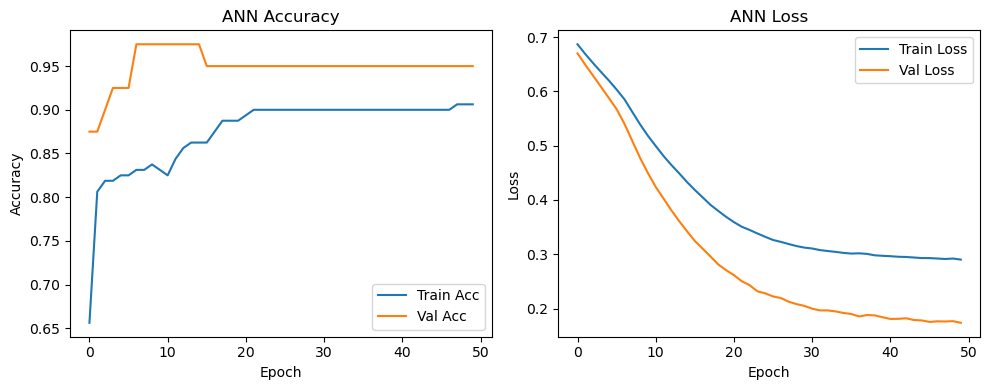

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ANN Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("ANN Loss")

plt.tight_layout()
plt.show()


In [ ]:
#GET ANN PREDICTIONS (PROBABILITIES + LABELS)

In [45]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Probabilities (important for ROC-AUC)
ann_prob = ann.predict(X_ann_test).ravel()

# Class predictions (0/1)
ann_pred = (ann_prob >= 0.5).astype(int)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


In [ ]:
#🔹  PRINT CORE METRICS

In [46]:
print("✅ ANN ENSEMBLE RESULTS")
print("Accuracy :", accuracy_score(y_ann_test, ann_pred))
print("ROC-AUC  :", roc_auc_score(y_ann_test, ann_prob))

print("\n📊 Classification Report:")
print(classification_report(y_ann_test, ann_pred))

print("🧭 Confusion Matrix:")
print(confusion_matrix(y_ann_test, ann_pred))


✅ ANN ENSEMBLE RESULTS
Accuracy : 0.95
ROC-AUC  : 0.9524999999999999

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40

🧭 Confusion Matrix:
[[19  1]
 [ 1 19]]


In [ ]:
#ROC CURVE (VERY IMPORTANT)

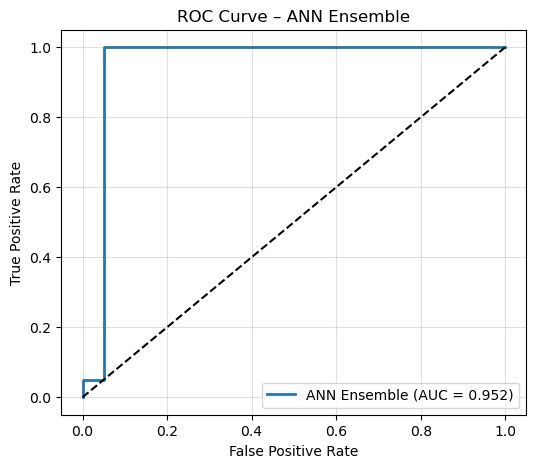

In [47]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_ann_test, ann_prob)
auc_score = roc_auc_score(y_ann_test, ann_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ANN Ensemble (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN Ensemble")
plt.legend()
plt.grid(alpha=0.4)
plt.show()
